Событие 10000/1000000, время: 6385.65/100000 мс
Событие 20000/1000000, время: 12762.78/100000 мс
Событие 30000/1000000, время: 19309.35/100000 мс
Событие 40000/1000000, время: 25802.35/100000 мс
Событие 50000/1000000, время: 32024.48/100000 мс
Событие 60000/1000000, время: 38361.90/100000 мс
Событие 70000/1000000, время: 44643.32/100000 мс
Событие 80000/1000000, время: 51114.35/100000 мс
Событие 90000/1000000, время: 57563.56/100000 мс
Событие 100000/1000000, время: 63808.17/100000 мс
Событие 110000/1000000, время: 70064.99/100000 мс
Событие 120000/1000000, время: 76390.13/100000 мс
Событие 130000/1000000, время: 82894.38/100000 мс
Событие 140000/1000000, время: 89283.47/100000 мс
Событие 150000/1000000, время: 95722.46/100000 мс

Результаты имитационной модели (M/M/3/3):
1. Вероятность простоя: 0.2633
2. Вероятность отказа: 0.1157
3. Относительная пропускная способность: 0.8843
4. Абсолютная пропускная способность: 0.7339
5. Среднее количество занятых процессоров: 1.2254

Аналитически

Построение графика: 100%|██████████| 10/10 [00:00<00:00, 29.38it/s]


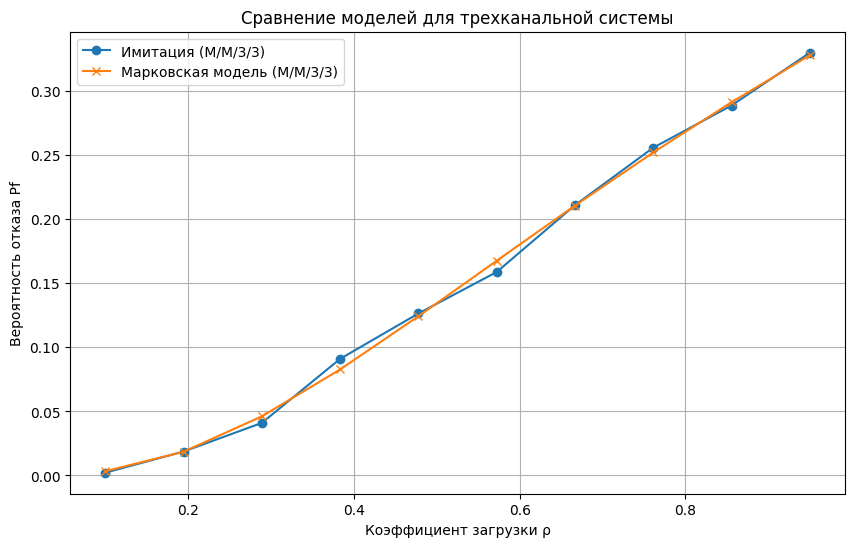


Минимальное количество каналов для Pf ≤ 0.01: 6


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import heapq
from tqdm import tqdm
import math


def mmcc_pf(rho, c):
    p = rho * c
    sum_ = sum(p**k / math.factorial(k) for k in range(c + 1))
    return (p**c / math.factorial(c)) / sum_


def run_simulation(lambda_, mu, num_processors, simulation_time, progress=False):
    heap = []
    first_arrival = np.random.exponential(1 / lambda_)
    heapq.heappush(heap, (first_arrival, "arrival"))

    busy = 0
    last_time = 0.0
    state_times = np.zeros(num_processors + 1)
    total_arrivals = 0
    rejections = 0

    event_count = 0
    max_events = 1_000_000

    while heap and event_count < max_events:
        current_time, event = heapq.heappop(heap)

        # Обновляем время состояний до текущего момента
        state_times[busy] += current_time - last_time
        last_time = current_time

        if event == "arrival":
            total_arrivals += 1

            if busy < num_processors:
                busy += 1
                # Генерируем departure без ограничения по времени
                departure_time = current_time + np.random.exponential(1 / mu)
                heapq.heappush(heap, (departure_time, "departure"))
            else:
                rejections += 1

            # Генерируем следующий arrival только если время не превышает симуляцию
            if current_time < simulation_time:
                next_arrival = current_time + np.random.exponential(1 / lambda_)
                heapq.heappush(heap, (next_arrival, "arrival"))

        elif event == "departure":
            busy = max(0, busy - 1)

        event_count += 1
        if progress and event_count % 10_000 == 0:
            print(
                f"Событие {event_count}/{max_events}, время: {current_time:.2f}/{simulation_time} мс"
            )

    # Добавляем оставшееся время после последнего события
    remaining_time = simulation_time - last_time
    if remaining_time > 0:
        state_times[busy] += remaining_time

    total_time = np.sum(state_times)
    p0 = state_times[0] / total_time if total_time > 0 else 1.0
    pf = rejections / total_arrivals if total_arrivals > 0 else 0.0
    rho = lambda_ / (num_processors * mu) if num_processors > 0 else 0.0

    return {
        "p0": p0,
        "pf": pf,
        "q": 1 - pf,
        "a": lambda_ * (1 - pf),
        "avg_busy": np.sum(np.arange(num_processors + 1) * state_times) / total_time,
        "rho": rho,
    }


# Параметры имитационной модели
lambda_initial = 0.83
mu_initial = 0.6
num_processors_initial = 3
simulation_time_initial = 100_000

# Запуск имитационной модели
results = run_simulation(
    lambda_initial,
    mu_initial,
    num_processors_initial,
    simulation_time_initial,
    progress=True,
)

# Вывод результатов имитационной модели
print("\nРезультаты имитационной модели (M/M/3/3):")
print(f"1. Вероятность простоя: {results['p0']:.4f}")
print(f"2. Вероятность отказа: {results['pf']:.4f}")
print(f"3. Относительная пропускная способность: {results['q']:.4f}")
print(f"4. Абсолютная пропускная способность: {results['a']:.4f}")
print(f"5. Среднее количество занятых процессоров: {results['avg_busy']:.4f}")

# Аналитические расчеты для одноканальной системы с накопителем (M/M/1/3)
p = lambda_initial / mu_initial
p0_mm1 = 1 / (1 + p + (p**2) / 2 + (p**3) / 6)
pf_mm1 = (p**3 / 6) * p0_mm1
q_mm1 = 1 - pf_mm1
a_mm1 = lambda_initial * q_mm1
avg_busy_mm1 = p * (1 - pf_mm1)

print("\nАналитические результаты для одноканальной системы с накопителем (M/M/1/3):")
print(f"1. Вероятность простоя: {p0_mm1:.4f}")
print(f"2. Вероятность отказа: {pf_mm1:.4f}")
print(f"3. Относительная пропускная способность: {q_mm1:.4f}")
print(f"4. Абсолютная пропускная способность: {a_mm1:.4f}")
print(f"5. Среднее число занятых каналов: {avg_busy_mm1:.4f}")


# Построение графика зависимости Pf от ρ
def plot_comparison(lambda_base, mu, c, max_rho=0.95, points=10):
    rhos = np.linspace(0.1, max_rho, points)
    sim_pfs = []
    theor_pfs = []

    for rho in tqdm(rhos, desc="Построение графика"):
        lambda_ = rho * c * mu
        res = run_simulation(lambda_, mu, c, 10_000, progress=False)
        sim_pfs.append(res["pf"])
        theor_pfs.append(mmcc_pf(rho, c))

    plt.figure(figsize=(10, 6))
    plt.plot(rhos, sim_pfs, "o-", label="Имитация (M/M/3/3)")
    plt.plot(rhos, theor_pfs, "x-", label="Марковская модель (M/M/3/3)")
    plt.xlabel("Коэффициент загрузки ρ")
    plt.ylabel("Вероятность отказа Pf")
    plt.title("Сравнение моделей для трехканальной системы")
    plt.legend()
    plt.grid(True)
    plt.show()


plot_comparison(0.83, 0.6, 3)


# Поиск минимального количества каналов для Pf ≤ 0.01
def find_min_channels(target_pf, lambda_, mu):
    c = 1
    while True:
        rho = lambda_ / (c * mu)
        if rho >= 1:
            c += 1
            continue
        pf = mmcc_pf(rho, c)
        if pf <= target_pf:
            return c
        c += 1


min_channels = find_min_channels(0.01, lambda_initial, mu_initial)
print(f"\nМинимальное количество каналов для Pf ≤ 0.01: {min_channels}")

In [ ]:
l = 0.83
nu1 = 0.6

p = l / nu1
p0 = 1 / (1 + p + (p**2) / 2 + (p**3) / 6 + (p**4) / 24)
pf = p**4 / ((1 + p + p**2 + p**3 + p**4) * 24)
q = 1 - pf
a = l * q
L = ((p**2) / 2 + 2 * (p**3) / 6 + 3 * (p**4) / 24) / (
    1 + p + (p**2) / 2 + (p**3) / 6 + (p**4) / 24
)
k = q * p
tr = L / l
tsys = tr + q / nu1

print(
    "p0: " + str(round(p0, 5)),
    "pf: " + str(round(pf, 5)),
    "Q: " + str(round(q, 5)),
    "a: " + str(round(a, 5)),
    "L: " + str(round(L, 5)),
    "k: " + str(round(k, 5)),
    "tr: " + str(round(tr, 5)),
    "tsys: " + str(round(tsys, 5)),
)
